In [3]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(readr)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Warning message:
“package ‘caret’ was built under R version 4.3.3”
Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [8]:
R.home()
system("which Rscript", intern = TRUE)
system("which -a Rscript", intern = TRUE)


[1] "/vol/projects/yzhang/miniconda3/envs/r4.3/lib/R"

[1] "/vol/biotools/alma8/R-4.2.0/bin/Rscript"

[1] "/vol/biotools/alma8/R-4.2.0/bin/Rscript"
[2] "/usr/bin/Rscript"

In [2]:
genotype <- read.csv("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/genotype_pca_scores.csv")
rownames(genotype) <- genotype[,1]
genotype <- genotype[,-1]
head(genotype)
dim(genotype)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC432,PC433,PC434,PC435,PC436,PC437,PC438,PC439,PC440,PC441
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV019,114.1161449,-19.38401,5.746826,-212.141208,35.13238,-19.684616,78.80395,-61.19517,93.69075,-70.49137,⋯,4.037625,0.6460441,-146.24867,12.245840,-93.65355,75.44545,-74.642075,101.24461,-127.904427,-6.421081e-13
HV021,97.8591066,-165.67695,2.910710,14.034495,113.45509,78.527501,167.36559,-47.93069,30.21846,11.42439,⋯,91.090139,47.9098819,70.23519,106.044788,23.63873,45.33377,-31.281777,-25.80193,-6.245470,-7.852063e-13
HV022,0.7887816,97.20417,112.825988,64.239274,-86.46565,270.423582,127.00337,119.10934,-65.15142,-31.41004,⋯,-50.670036,-138.4198945,49.81079,-138.567689,-14.61836,-139.66799,-110.109301,-48.68582,4.630899,-6.970351e-13
HV026,-41.4839679,-73.39533,138.556287,-18.768902,16.29466,-93.293634,-36.39892,-42.14787,-42.47860,189.30274,⋯,-74.313117,-169.0504870,-119.25703,159.710273,-139.59927,-28.09913,91.480177,-105.49365,-40.244513,-4.349745e-13
HV028,-232.3025298,278.79275,90.383068,5.023908,122.18491,-58.422384,-58.98908,155.00884,94.78593,137.94146,⋯,82.565593,-21.4031760,11.41038,-2.920895,72.39695,16.60280,-3.398263,206.81660,-47.263624,-7.240675e-13
HV029,139.3300167,35.35750,-14.899650,123.688788,29.00413,5.925495,-41.75919,39.62702,-334.35934,61.24630,⋯,59.733659,177.2467651,105.89253,36.050890,-42.74096,-60.60274,73.554598,-80.06630,73.580396,-7.236280e-13


[1] 441 441

In [3]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
# prepare cytokine_filter and EAA_filter_match
idx = intersect(rownames(genotype), basicPhenos$ID_500fg) 
length(idx) #458samples
genotype_filter = genotype[which(rownames(genotype) %in% idx),]
head(genotype_filter)  #458samples,1596 metabolite
dim(genotype_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(genotype_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(genotype_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(genotype_filter))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 435

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC432,PC433,PC434,PC435,PC436,PC437,PC438,PC439,PC440,PC441
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV019,114.1161449,-19.38401,5.746826,-212.141208,35.13238,-19.684616,78.80395,-61.19517,93.69075,-70.49137,⋯,4.037625,0.6460441,-146.24867,12.245840,-93.65355,75.44545,-74.642075,101.24461,-127.904427,-6.421081e-13
HV021,97.8591066,-165.67695,2.910710,14.034495,113.45509,78.527501,167.36559,-47.93069,30.21846,11.42439,⋯,91.090139,47.9098819,70.23519,106.044788,23.63873,45.33377,-31.281777,-25.80193,-6.245470,-7.852063e-13
HV022,0.7887816,97.20417,112.825988,64.239274,-86.46565,270.423582,127.00337,119.10934,-65.15142,-31.41004,⋯,-50.670036,-138.4198945,49.81079,-138.567689,-14.61836,-139.66799,-110.109301,-48.68582,4.630899,-6.970351e-13
HV026,-41.4839679,-73.39533,138.556287,-18.768902,16.29466,-93.293634,-36.39892,-42.14787,-42.47860,189.30274,⋯,-74.313117,-169.0504870,-119.25703,159.710273,-139.59927,-28.09913,91.480177,-105.49365,-40.244513,-4.349745e-13
HV028,-232.3025298,278.79275,90.383068,5.023908,122.18491,-58.422384,-58.98908,155.00884,94.78593,137.94146,⋯,82.565593,-21.4031760,11.41038,-2.920895,72.39695,16.60280,-3.398263,206.81660,-47.263624,-7.240675e-13
HV029,139.3300167,35.35750,-14.899650,123.688788,29.00413,5.925495,-41.75919,39.62702,-334.35934,61.24630,⋯,59.733659,177.2467651,105.89253,36.050890,-42.74096,-60.60274,73.554598,-80.06630,73.580396,-7.236280e-13


[1] 435 441

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
6,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1


[1] 435  18

[1] 3

[1] 435

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
167,69,HV019,male,22,175,79,25.79592,Cohabitation,Hogeschool opleiding (HBO),European,Never,No,Yes,11,11,311,2013,Group 3
161,1,HV021,male,22,185,88,25.71220,Single living alone,University student,European,Rarely,No,Yes,16,12,346,2013,Group 3
80,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
166,60,HV026,female,22,176,74,23.88946,Cohabitation,University student,European,Rarely,No,Yes,18,11,318,2013,Group 3
347,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
260,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4


[1] 435  18

In [4]:
genotype_age <- cbind(genotype_filter, Age = basicPhenos_filter_match$Age)
head(genotype_age)
dim(genotype_age)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC433,PC434,PC435,PC436,PC437,PC438,PC439,PC440,PC441,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV019,114.1161449,-19.38401,5.746826,-212.141208,35.13238,-19.684616,78.80395,-61.19517,93.69075,-70.49137,⋯,0.6460441,-146.24867,12.245840,-93.65355,75.44545,-74.642075,101.24461,-127.904427,-6.421081e-13,22
HV021,97.8591066,-165.67695,2.910710,14.034495,113.45509,78.527501,167.36559,-47.93069,30.21846,11.42439,⋯,47.9098819,70.23519,106.044788,23.63873,45.33377,-31.281777,-25.80193,-6.245470,-7.852063e-13,22
HV022,0.7887816,97.20417,112.825988,64.239274,-86.46565,270.423582,127.00337,119.10934,-65.15142,-31.41004,⋯,-138.4198945,49.81079,-138.567689,-14.61836,-139.66799,-110.109301,-48.68582,4.630899,-6.970351e-13,20
HV026,-41.4839679,-73.39533,138.556287,-18.768902,16.29466,-93.293634,-36.39892,-42.14787,-42.47860,189.30274,⋯,-169.0504870,-119.25703,159.710273,-139.59927,-28.09913,91.480177,-105.49365,-40.244513,-4.349745e-13,22
HV028,-232.3025298,278.79275,90.383068,5.023908,122.18491,-58.422384,-58.98908,155.00884,94.78593,137.94146,⋯,-21.4031760,11.41038,-2.920895,72.39695,16.60280,-3.398263,206.81660,-47.263624,-7.240675e-13,29
HV029,139.3300167,35.35750,-14.899650,123.688788,29.00413,5.925495,-41.75919,39.62702,-334.35934,61.24630,⋯,177.2467651,105.89253,36.050890,-42.74096,-60.60274,73.554598,-80.06630,73.580396,-7.236280e-13,24


[1] 435 442

In [5]:
#Age
#split data to trianing and testing set
set.seed(1)
splitSample <- createDataPartition(genotype_age$Age, p = 0.7, list = FALSE)
training <- genotype_age[splitSample,]
validation <- genotype_age[-splitSample,]

#settings grid tuning and cv
netGrid <- expand.grid(.alpha=1,.lambda=seq(0,1,by=0.01))  
netctrl <- trainControl(method="repeatedcv", number=10, repeats=5) 

#training
netFit <- train(Age~.,data = training, method = 'glmnet', metric = "RMSE",tuneGrid=netGrid,trControl = netctrl,preProcess = "scale")

#look at the model
head(arrange(netFit$results, RMSE) )

netFit$bestTune

my.glmnet.model<- netFit$finalModel
aa<- as.matrix(coef(my.glmnet.model,s=netFit$bestTune$lambda))
b<-as.data.frame(aa[which(aa[,1]!=0),])
colnames(b)<-"coef"
b

,alpha,lambda,RMSE,Rsquared,MAE,RMSESD,RsquaredSD,MAESD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1.00,13.32243,0.04952125,9.442917,1.715419,0.06051064,1.252613
2,1,0.99,13.32851,0.04951198,9.452046,1.714101,0.06093412,1.253208
3,1,0.98,13.33456,0.04950035,9.460936,1.712694,0.06136544,1.253842
4,1,0.97,13.34034,0.04949770,9.469163,1.711115,0.06178178,1.254533
5,1,0.96,13.34606,0.04950211,9.477227,1.709929,0.06222128,1.255368
6,1,0.95,13.35144,0.04951702,9.485409,1.709432,0.06269573,1.256175


,alpha,lambda
,<dbl>,<dbl>
101,1,1


,coef
,<dbl>
(Intercept),27.972119926
PC5,-0.232862655
PC6,-0.299639736
PC9,-0.273193162
PC12,0.611103156
PC15,-0.006089850
PC18,-0.314868319
PC19,0.093638004
PC24,0.512193930


In [6]:
#Prediction on validation set
predictions <- predict(netFit, validation)

cor.test(predictions,validation$Age)

RMSE(predictions,validation$Age)


	Pearson's product-moment correlation

data:  predictions and validation$Age
t = -0.043416, df = 127, p-value = 0.9654
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1765893  0.1691145
sample estimates:
         cor 
-0.003852521 


[1] 14.02086

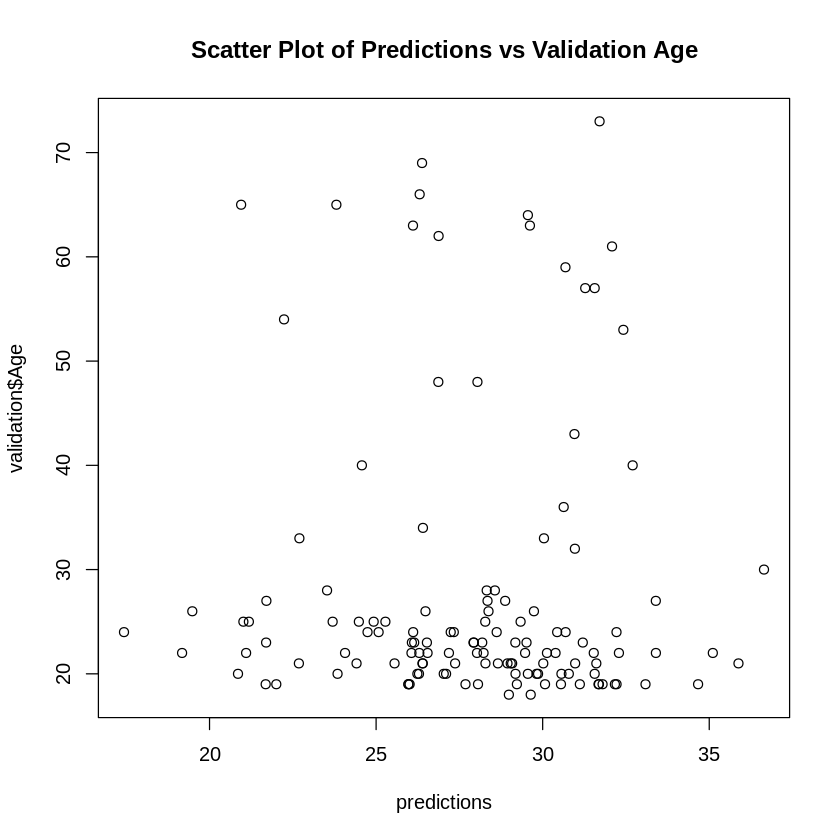

In [7]:
plot(predictions, validation$Age,
     xlab = "predictions", 
     ylab = "validation$Age",
     main = "Scatter Plot of Predictions vs Validation Age",
     pch = 1)  # pch = 1 present circle

In [8]:
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Set up the grid for hyperparameter tuning
  netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit
  )
}

In [9]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(genotype_age, seed = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,10.44916508,0.67826731
2,Validation RMSE,13.43177455,0.81562635
3,Train MSE,109.64049694,11.52190015
4,Validation MSE,181.07116147,22.03125653
5,Train R²,0.57162561,0.05598402
6,Validation R²,0.01965822,0.01884097


png 
  2

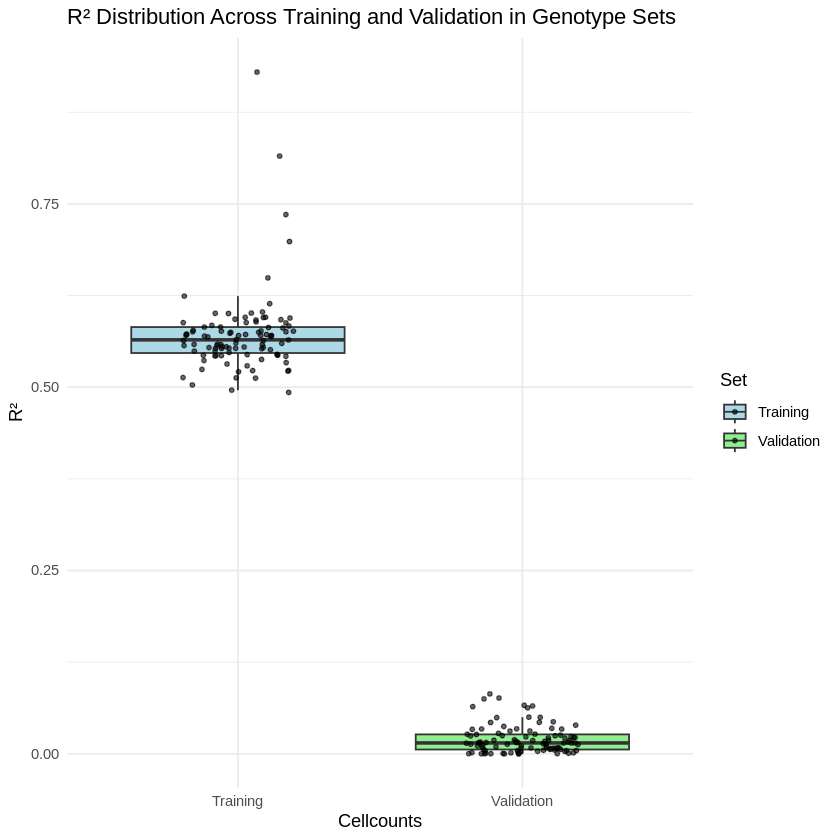

In [10]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
png("/vol/projects/yzhang/500FG_aging/output/04_genotype/genotype_cross_validation.png", 
    width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Genotype Sets",
       x = "Cellcounts",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [ ]:
save.image("/vol/projects/yzhang/500FG_aging/output/04_genotype/genotype_prediction.Rdata")

In [1]:
### raw data with high variance
results<-readRDS("/vol/projects/yzhang/500FG_aging/input/methylation/prediction/genotype_prediction_results.rds")  

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,1.034095e+01,0.275533827
2,Validation RMSE,1.368301e+01,0.799285778
3,Train MSE,1.070104e+02,5.623813316
4,Validation MSE,1.878571e+02,21.873191563
5,Train R²,5.912101e-01,0.034523461
6,Validation R²,7.726888e-03,0.008825876


png 
  2

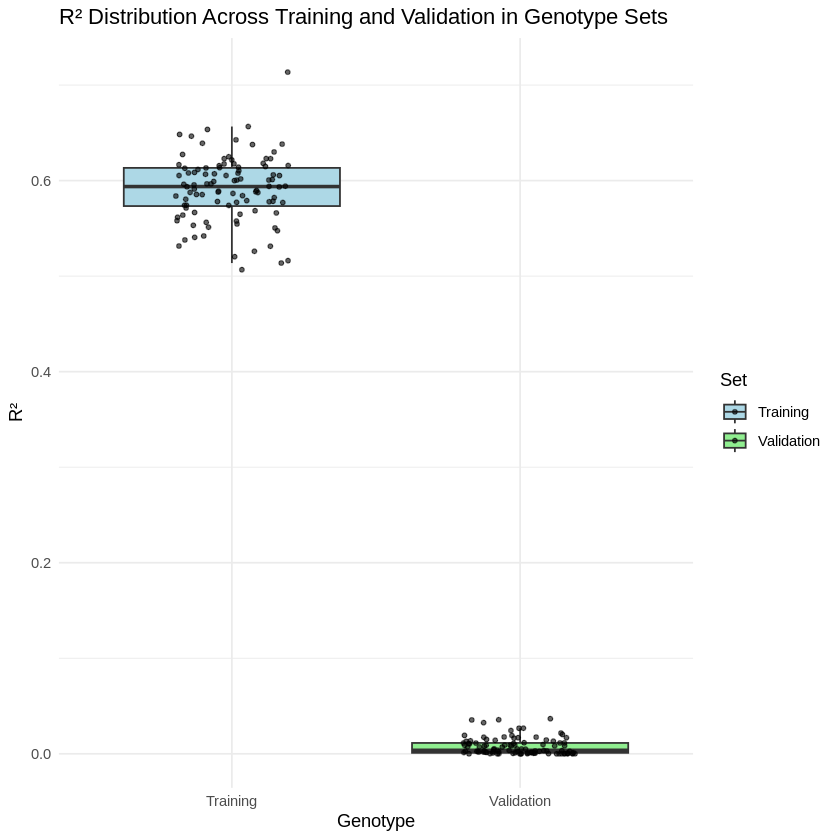

In [4]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
png("/vol/projects/yzhang/500FG_aging/output/04_genotype/genotype_cross_validation(raw data).png", 
    width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Genotype Sets",
       x = "Genotype",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)                        

In [5]:
save.image("/vol/projects/yzhang/500FG_aging/output/04_genotype/genotype_prediction_raw.Rdata")